# ANTARAGA - Stroke Prediction

## Import Libraries

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style yang mudah dibaca (font & kontras)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120

## EDA

In [157]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [158]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [159]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [160]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(col)
        print(df[col].unique())

In [161]:
df.drop('id', axis=1, inplace=True)
df.shape

(5110, 11)

In [162]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [163]:
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())
df.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

## Visualisasi (Jelas & Terbaca)

### 1. Pairplot — hanya numerik + stroke (lebih jelas)
Menggunakan 3 variabel numerik utama agar tidak penuh dan bisa dibaca. Warna: biru = tidak stroke, oranye = stroke.

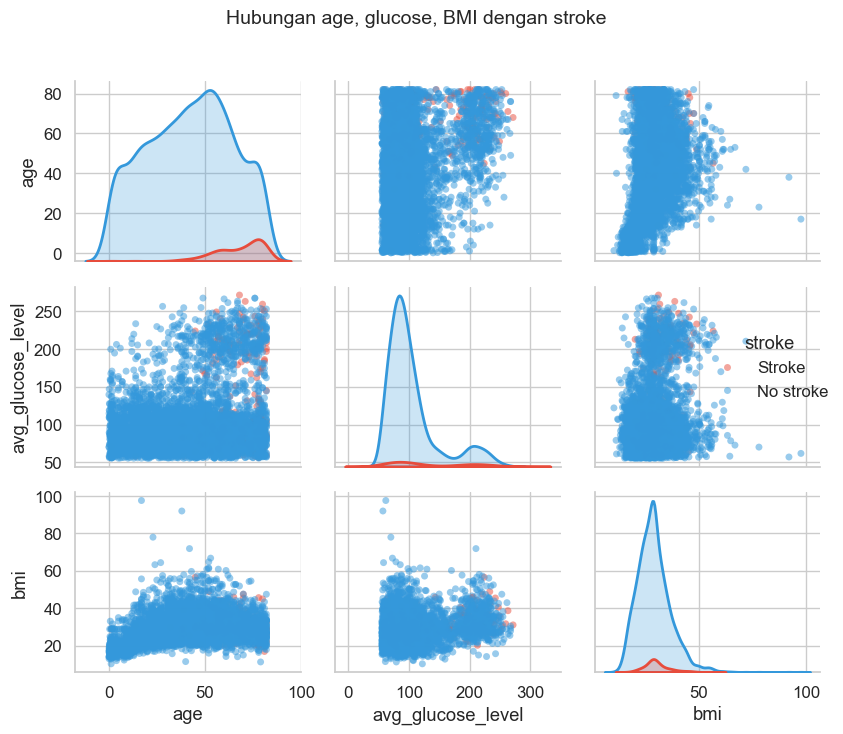

In [164]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
plot_df = df[num_cols].copy()
plot_df['stroke'] = df['stroke'].map({0: 'No stroke', 1: 'Stroke'})

g = sns.pairplot(
    plot_df,
    hue='stroke',
    # hue_order=['No stroke', 'Stroke'],
    hue_order=['Stroke', 'No stroke'],
    palette={'No stroke': '#3498db', 'Stroke': '#e74c3c'},
    diag_kind='kde',
    plot_kws=dict(alpha=0.5, s=25, edgecolor='none'),
    diag_kws=dict(linewidth=2),
    height=2.4,
    corner=False
)
g.figure.suptitle('Hubungan age, glucose, BMI dengan stroke', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 2. KDE numerik (distribution)

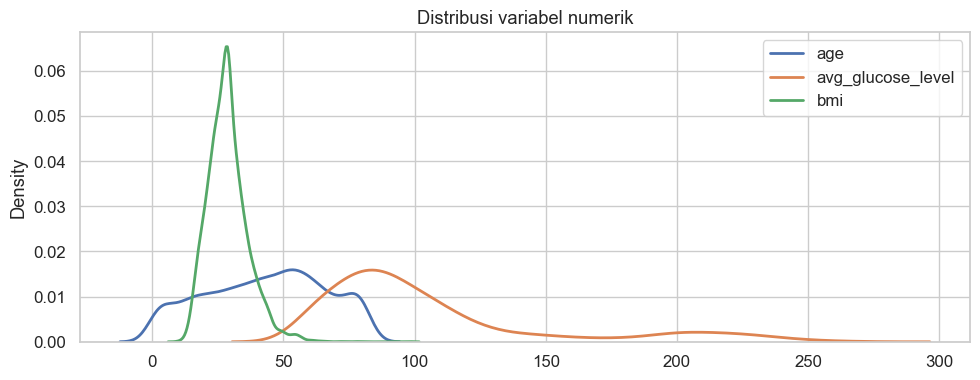

In [165]:
fig, ax = plt.subplots(figsize=(10, 4))
for col in ['age', 'avg_glucose_level', 'bmi']:
    sns.kdeplot(data=df, x=col, ax=ax, label=col, linewidth=2)
ax.set_title('Distribusi variabel numerik')
ax.legend()
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### 3. Countplot Stroke — dengan total & persentase di bar

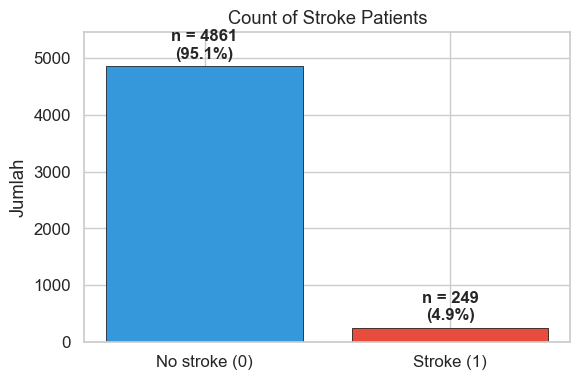

In [166]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['stroke'].value_counts().sort_index()
labels = ['No stroke (0)', 'Stroke (1)']
colors = ['#3498db', '#e74c3c']
bars = ax.bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Jumlah')
ax.set_title('Count of Stroke Patients')
total = counts.sum()
for bar, c in zip(bars, counts.values):
    pct = 100 * c / total
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f'n = {c}\n({pct:.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, counts.max() + 600)
plt.tight_layout()
plt.show()

### 4. Countplot kategorik vs stroke — dengan total per segmen

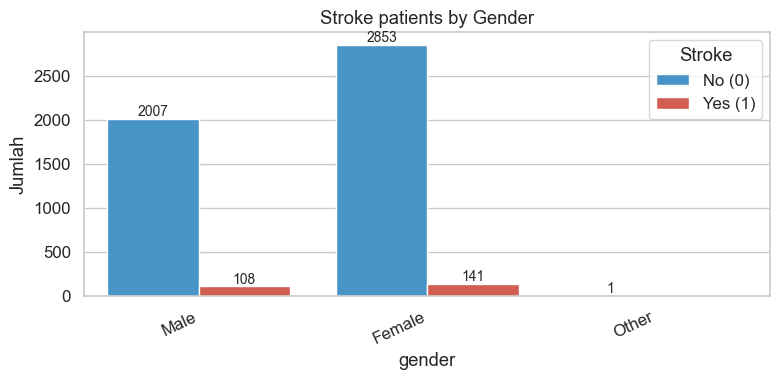

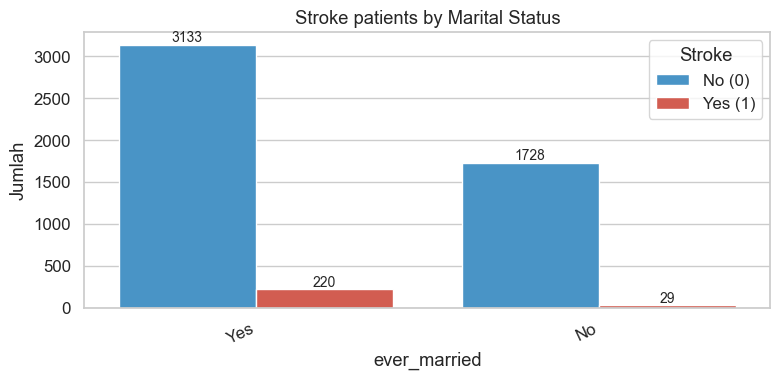

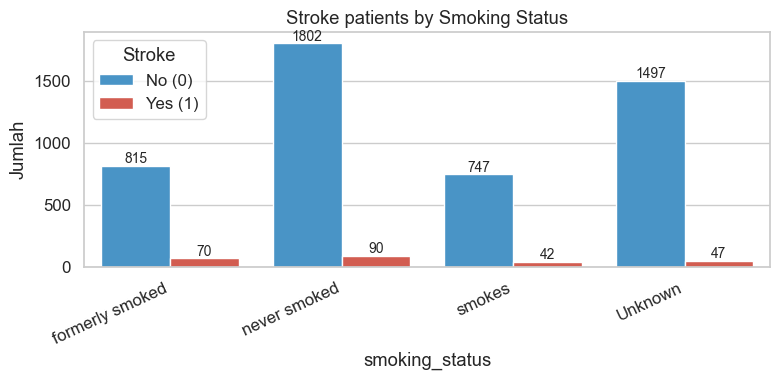

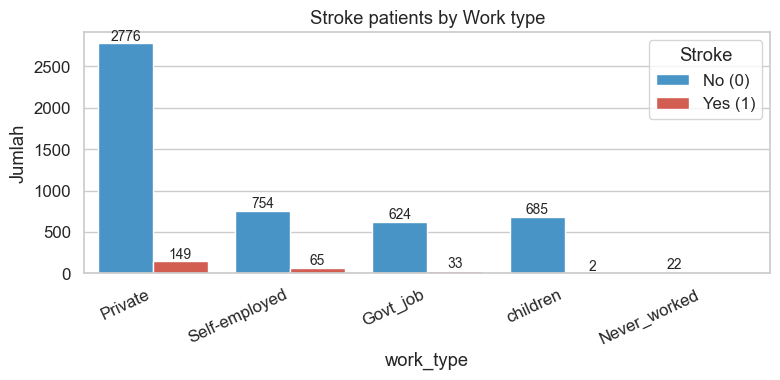

In [167]:
def countplot_with_totals(df, x, hue='stroke', title=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    hue_order = [0, 1] if hue == 'stroke' else None
    ax = sns.countplot(data=df, x=x, hue=hue, hue_order=hue_order, palette={0: '#3498db', 1: '#e74c3c'})
    ax.set_title(title or f'Stroke by {x}')
    ax.set_ylabel('Jumlah')
    ax.legend(title='Stroke', labels=['No (0)', 'Yes (1)'])
    # Tambah angka di setiap bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

countplot_with_totals(df, 'gender', title='Stroke patients by Gender')
countplot_with_totals(df, 'ever_married', title='Stroke patients by Marital Status')
countplot_with_totals(df, 'smoking_status', title='Stroke patients by Smoking Status')
countplot_with_totals(df, 'work_type', title='Stroke patients by Work type')

### 5. Residence type (Urban/Rural)

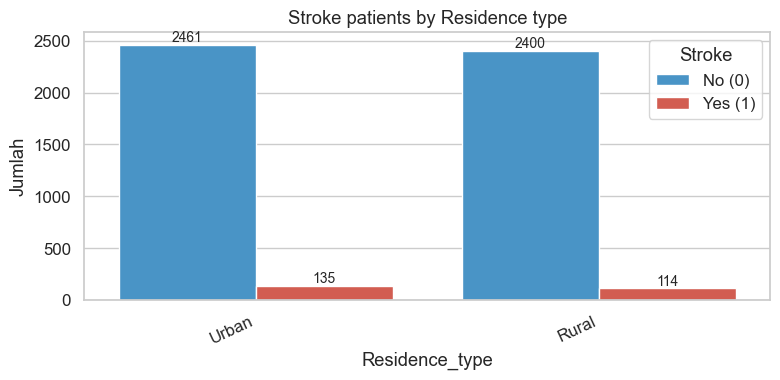

In [168]:
countplot_with_totals(df, 'Residence_type', title='Stroke patients by Residence type')

### 6. Grid: Boxplot, Histogram, Line (age / glucose / BMI)

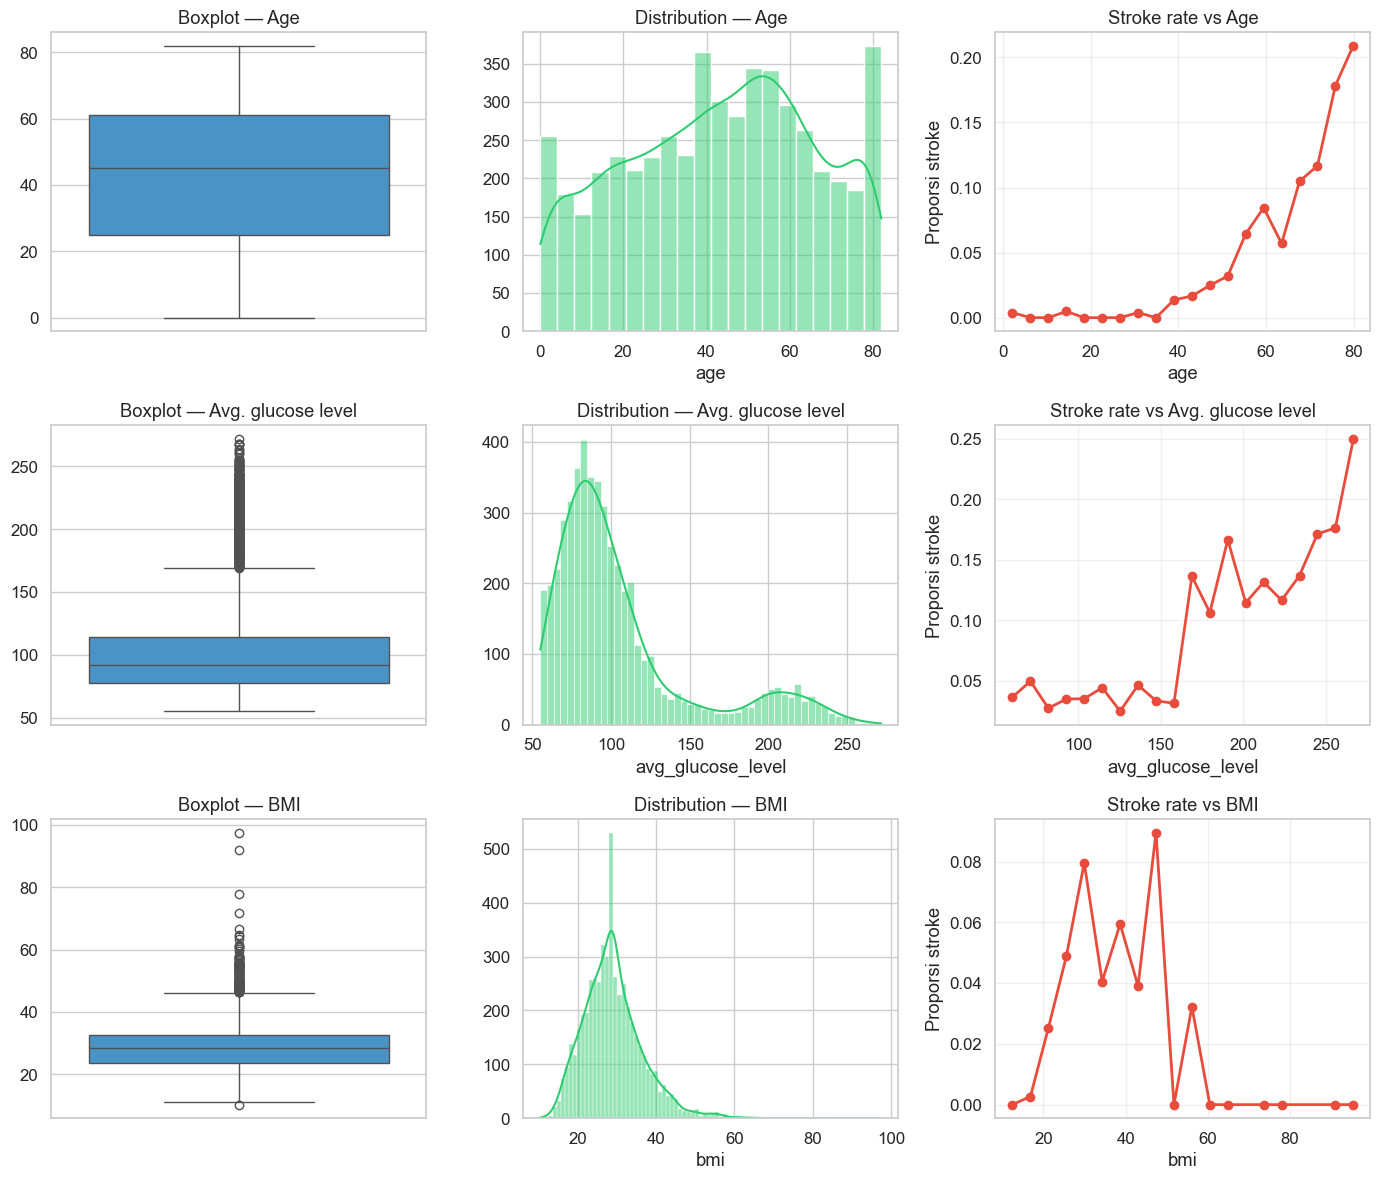

In [169]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

cols = ['age', 'avg_glucose_level', 'bmi']
titles = ['Age', 'Avg. glucose level', 'BMI']

for i, (col, title) in enumerate(zip(cols, titles)):
    # Boxplot
    sns.boxplot(data=df, y=col, ax=axes[i, 0], color='#3498db')
    axes[i, 0].set_ylabel('')
    axes[i, 0].set_title(f'Boxplot — {title}')
    # Histogram
    sns.histplot(data=df, x=col, kde=True, ax=axes[i, 1], color='#2ecc71')
    axes[i, 1].set_ylabel('')
    axes[i, 1].set_title(f'Distribution — {title}')
    # Line (rata-rata stroke per bin)
    binned = pd.cut(df[col], bins=min(20, df[col].nunique()))
    rate = df.groupby(binned)['stroke'].mean()
    mid = [interval.mid for interval in rate.index]
    axes[i, 2].plot(mid, rate.values, 'o-', color='#e74c3c', linewidth=2, markersize=6)
    axes[i, 2].set_xlabel(col)
    axes[i, 2].set_ylabel('Proporsi stroke')
    axes[i, 2].set_title(f'Stroke rate vs {title}')
    axes[i, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

    ### 7. Heatmap korelasi — lebih besar & angka terbaca

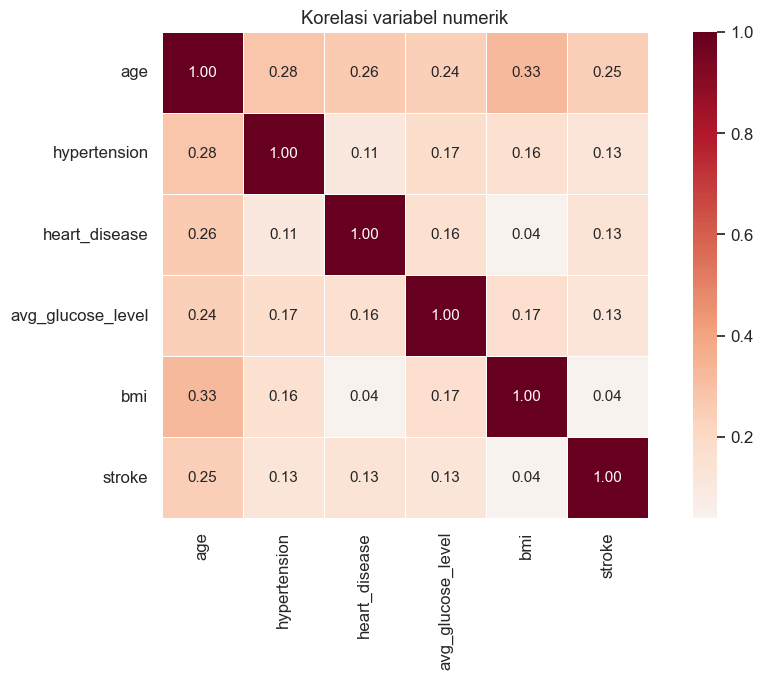

In [170]:
corr = df.select_dtypes(include='number').corr()
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Korelasi variabel numerik')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [171]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object' or pd.api.types.is_string_dtype(df[col]):
        df[col] = le.fit_transform(df[col].astype(str))
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,0,79.0,1,0,1,3,0,174.12,24.000000,2,1


In [172]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
for col_name in df.columns:
    if df[col_name].nunique() > 5:
        df[col_name] = scaler.fit_transform(df[[col_name]])

X = df.drop("stroke", axis=1)
y = df["stroke"]

In [173]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)

## Building Models

### Decision Tree

In [174]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import sklearn.metrics as mt

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
accuracy_using_decision_tree = round(accuracy_score(y_test, y_pred_dt) * 100, 2)
print("Model accuracy using Decision Tree:", accuracy_using_decision_tree, "%")

Model accuracy using Decision Tree: 90.41 %


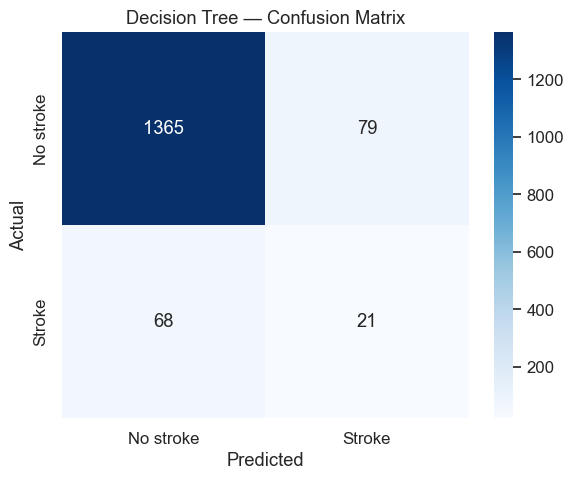

In [175]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = mt.confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No stroke', 'Stroke'], yticklabels=['No stroke', 'Stroke'])
ax.set_title('Decision Tree — Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Support Vector Machine

In [176]:
from sklearn import svm

svm_model = svm.SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_using_svm = round(accuracy_score(y_test, y_pred_svm) * 100, 2)
print("Model accuracy using SVM:", accuracy_using_svm, "%")

Model accuracy using SVM: 94.19 %


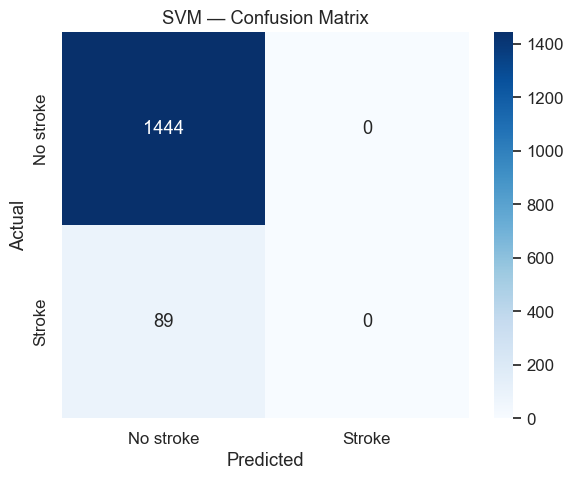

In [ ]:

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

TN, FP, FN, TP = cm.ravel()

# Hitung metrik
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

# Print rumus dan hasil
print("Precision = TP / (TP + FP)")
print(f"Precision = {TP} / ({TP} + {FP}) = {precision:.4f}\n")

print("Recall = TP / (TP + FN)")
print(f"Recall = {TP} / ({TP} + {FN}) = {recall:.4f}\n")

print("F1 Score = 2 * (Precision * Recall) / (Precision + Recall)")
print(f"F1 Score = {f1:.4f}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    xticklabels=['No stroke', 'Stroke'],
    yticklabels=['No stroke', 'Stroke']
)

ax.set_title('Decision Tree — Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Logistic Regression

In [178]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
accuracy_using_logistic_regression = round(accuracy_score(y_test, y_pred_lr) * 100, 2)
print("Model accuracy using Logistic Regression:", accuracy_using_logistic_regression, "%")

Model accuracy using Logistic Regression: 94.19 %


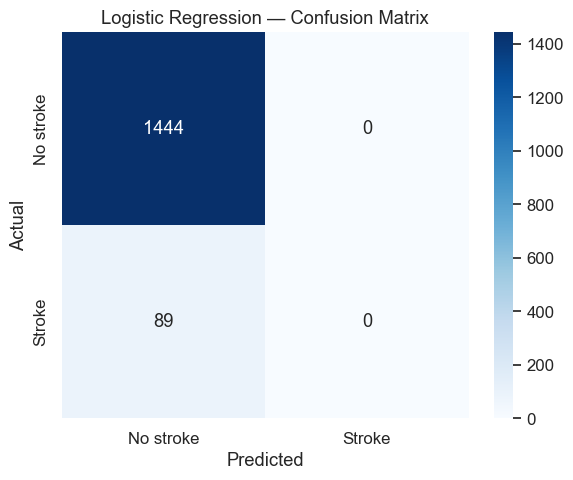

In [179]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = mt.confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No stroke', 'Stroke'], yticklabels=['No stroke', 'Stroke'])
ax.set_title('Logistic Regression — Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Random Forest

In [180]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = round(accuracy_score(y_test, y_pred_rf) * 100, 2)
print("Model accuracy using Random Forest:", acc_rf, "%")

Model accuracy using Random Forest: 94.06 %


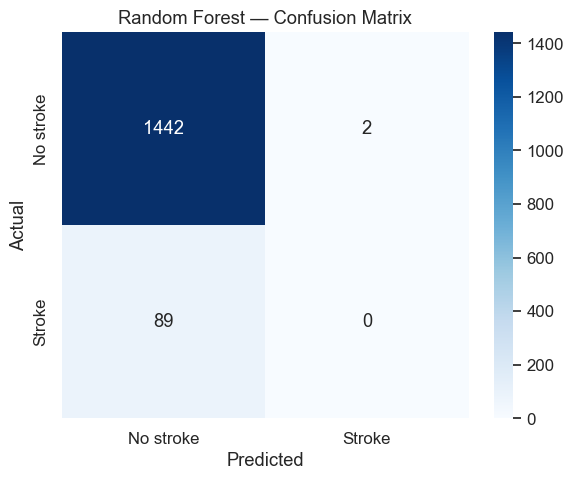

In [181]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = mt.confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No stroke', 'Stroke'], yticklabels=['No stroke', 'Stroke'])
ax.set_title('Random Forest — Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### XGBoost

In [184]:
y_pred_xgb = None  # default jika XGBoost gagal load
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(random_state=42)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    acc_xgb = round(accuracy_score(y_test, y_pred_xgb) * 100, 2)
    print("Model accuracy using XGBoost:", acc_xgb, "%")
except ImportError:
    print("XGBoost tidak terpasang. Install: pip install xgboost")
except Exception as e:
    print("XGBoost error:", type(e).__name__)
    print("Di Mac, coba: brew install libomp lalu restart kernel & jalankan ulang.")
    y_pred_xgb = None

Model accuracy using XGBoost: 94.06 %


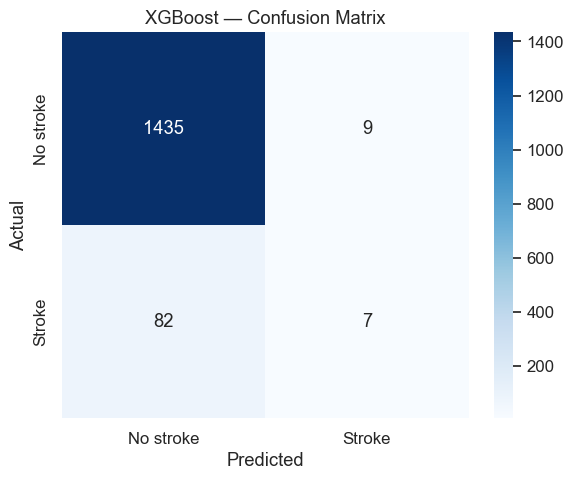

In [185]:
if y_pred_xgb is not None:
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = mt.confusion_matrix(y_test, y_pred_xgb)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No stroke', 'Stroke'], yticklabels=['No stroke', 'Stroke'])
    ax.set_title('XGBoost — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

### Ringkasan perbandingan model

In [186]:
summary = [
    ("Decision Tree", accuracy_using_decision_tree),
    ("Random Forest", acc_rf),
    ("Gradient Boosting", acc_gbm),
    ("SVM", accuracy_using_svm),
    ("Logistic Regression", accuracy_using_logistic_regression),
]
try:
    if y_pred_xgb is not None:
        summary.append(("XGBoost", acc_xgb))
except NameError:
    pass
pd.DataFrame(summary, columns=["Model", "Accuracy (%)"]).sort_values("Accuracy (%)", ascending=False)

,Model,Accuracy (%)
2,Gradient Boosting,94.32
3,SVM,94.19
4,Logistic Regression,94.19
1,Random Forest,94.06
5,XGBoost,94.06
0,Decision Tree,90.41
